In [16]:
from thinkbayes import Suite

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'YuGothic'

class Euro2(Suite):

    def Likelihood(self, data, hypo):

        x = hypo / 100.0
        heads, tails = data
        like = x**heads * (1-x)**tails

        return like


55.95238095238096


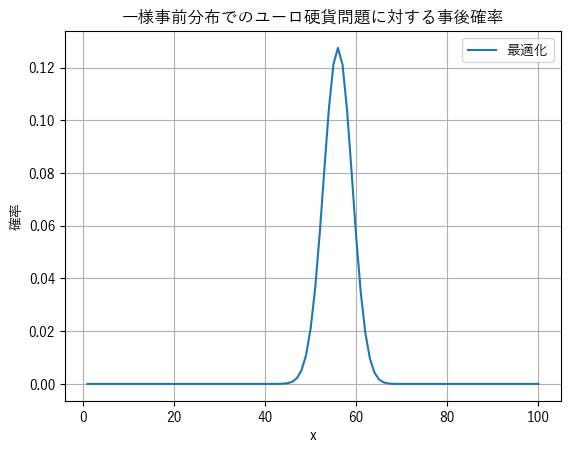

In [18]:
posts = range(1,101)
suite = Euro2(posts)

heads, tails = 140, 110
suite.Update((heads, tails))

post = [v for k, v in suite.Items()]

print(suite.Mean())

hypos = range(1,101)

plt.plot(hypos, post, label="最適化")

plt.xlabel('x')
plt.ylabel('確率')

plt.title('一様事前分布でのユーロ硬貨問題に対する事後確率')
plt.legend()
plt.grid(True)

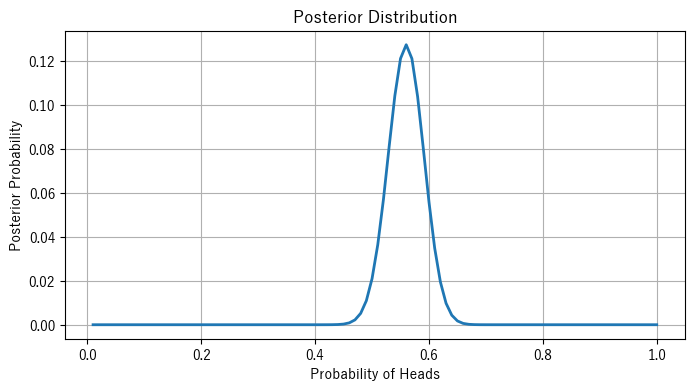

In [29]:
import numpy as np

# -----------------------------
# 仮説（表の出る確率）
# -----------------------------
p = np.arange(1, 101) / 100      # 0.01 ～ 1.00

# -----------------------------
# 観測データ　140, 110
# -----------------------------
heads = 140
tails = 110

# -----------------------------
# 事前分布（一様分布）
# -----------------------------
prior = np.ones_like(p)
prior /= prior.sum()

# -----------------------------
# 尤度
# -----------------------------
likelihood = p**heads * (1-p)**tails

# -----------------------------
# 事後分布
# -----------------------------
posterior = prior * likelihood
posterior /= posterior.sum()

# -----------------------------
# グラフ
# -----------------------------
plt.figure(figsize=(8,4))
plt.plot(p, posterior, lw=2)
plt.xlabel("Probability of Heads")
plt.ylabel("Posterior Probability")
plt.title("Posterior Distribution")
plt.grid(True)
plt.show()

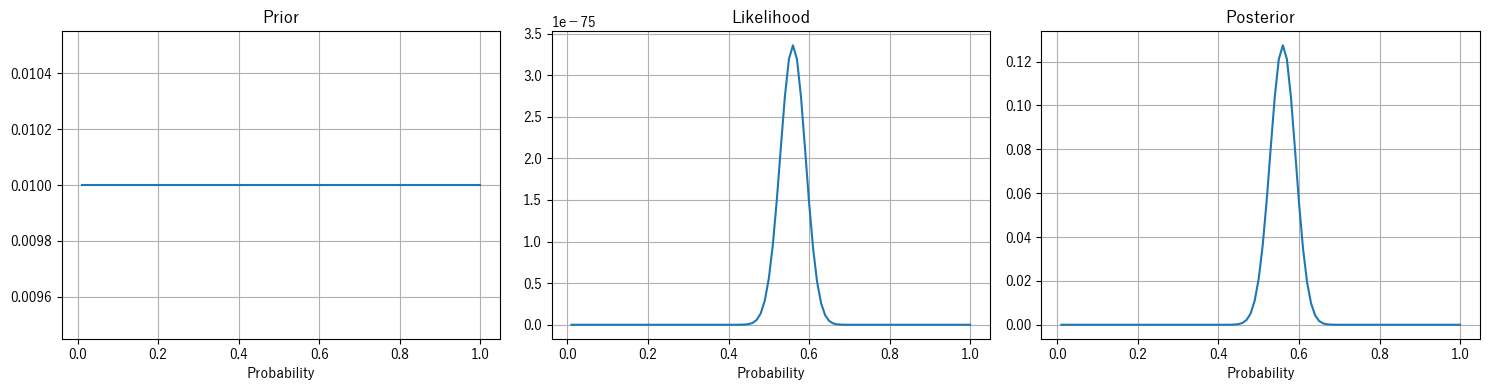

In [30]:
titles = ["Prior", "Likelihood", "Posterior"]
datas = [prior, likelihood, posterior]

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, data, title in zip(axes, datas, titles):
    ax.plot(p, data)
    ax.set_title(title)
    ax.set_xlabel("Probability")
    ax.grid(True)

plt.tight_layout()
plt.show()